In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score,
)

# Classification Evaluation
Load test results from the pipeline and evaluate accuracy at main and sub category level.

In [3]:
results = pd.read_csv("data/reports/classification_test_results.csv")
print(f"Loaded {len(results)} test cases")
print(f"Main category accuracy: {results['main_correct'].mean():.1%}")
print(f"Sub category accuracy:  {results['sub_correct'].mean():.1%}")
print(f"\nColumns: {list(results.columns)}")

Loaded 319 test cases
Main category accuracy: 90.3%
Sub category accuracy:  80.9%

Columns: ['retrieval_text', 'llm_context', 'nam_main_category', 'nam_sub_category', 'predicted_main', 'predicted_sub', 'retrieval_majority_label', 'main_correct', 'sub_correct']


## Per-category metrics helper

In [4]:
def per_category_metrics(y_true, y_pred):
    """
    Per-category Precision, Recall, F1, Support.
    Treats each category as one-vs-rest. Sorted by F1 (worst first).
    """
    categories = sorted(set(y_true) | set(y_pred))
    rows = []

    for cat in categories:
        tp = sum((t == cat) and (p == cat) for t, p in zip(y_true, y_pred))
        fp = sum((t != cat) and (p == cat) for t, p in zip(y_true, y_pred))
        fn = sum((t == cat) and (p != cat) for t, p in zip(y_true, y_pred))

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

        rows.append({
            "category": cat,
            "precision": round(precision, 3),
            "recall": round(recall, 3),
            "f1": round(f1, 3),
            "support": tp + fn,
            "correct": tp,
            "errors": fn,
        })

    return pd.DataFrame(rows).sort_values("f1", ascending=True).reset_index(drop=True)

## Main category metrics

In [5]:
y_true_main = results["nam_main_category"].tolist()
y_pred_main = results["predicted_main"].tolist()

main_metrics = per_category_metrics(y_true_main, y_pred_main)
print(main_metrics.to_string(index=False))

print(f"\nOverall accuracy: {accuracy_score(y_true_main, y_pred_main):.1%}")
print(f"Macro avg  \u2014 P: {precision_score(y_true_main, y_pred_main, average='macro', zero_division=0):.3f}  "
      f"R: {recall_score(y_true_main, y_pred_main, average='macro', zero_division=0):.3f}  "
      f"F1: {f1_score(y_true_main, y_pred_main, average='macro', zero_division=0):.3f}")
print(f"Weighted avg \u2014 P: {precision_score(y_true_main, y_pred_main, average='weighted', zero_division=0):.3f}  "
      f"R: {recall_score(y_true_main, y_pred_main, average='weighted', zero_division=0):.3f}  "
      f"F1: {f1_score(y_true_main, y_pred_main, average='weighted', zero_division=0):.3f}")

            category  precision  recall    f1  support  correct  errors
                 sfb      0.000   0.000 0.000        0        0       0
               other      0.500   0.333 0.400        3        1       2
       image_quality      0.667   1.000 0.800        2        2       0
       environmental      1.000   0.688 0.815       16       11       5
       reconstructor      1.000   0.714 0.833        7        5       2
              magnet      0.778   0.933 0.848       15       14       1
                coil      0.833   0.909 0.870       22       20       2
            software      0.923   0.828 0.873       29       24       5
    data_acquisition      0.906   0.853 0.879       34       29       5
     patient_support      0.870   0.952 0.909       42       40       2
      cooling_system      0.870   0.952 0.909       21       20       1
            consoles      0.946   0.897 0.921       39       35       4
        gradient_amp      0.947   0.947 0.947       38       36 

## Main category confusion matrix

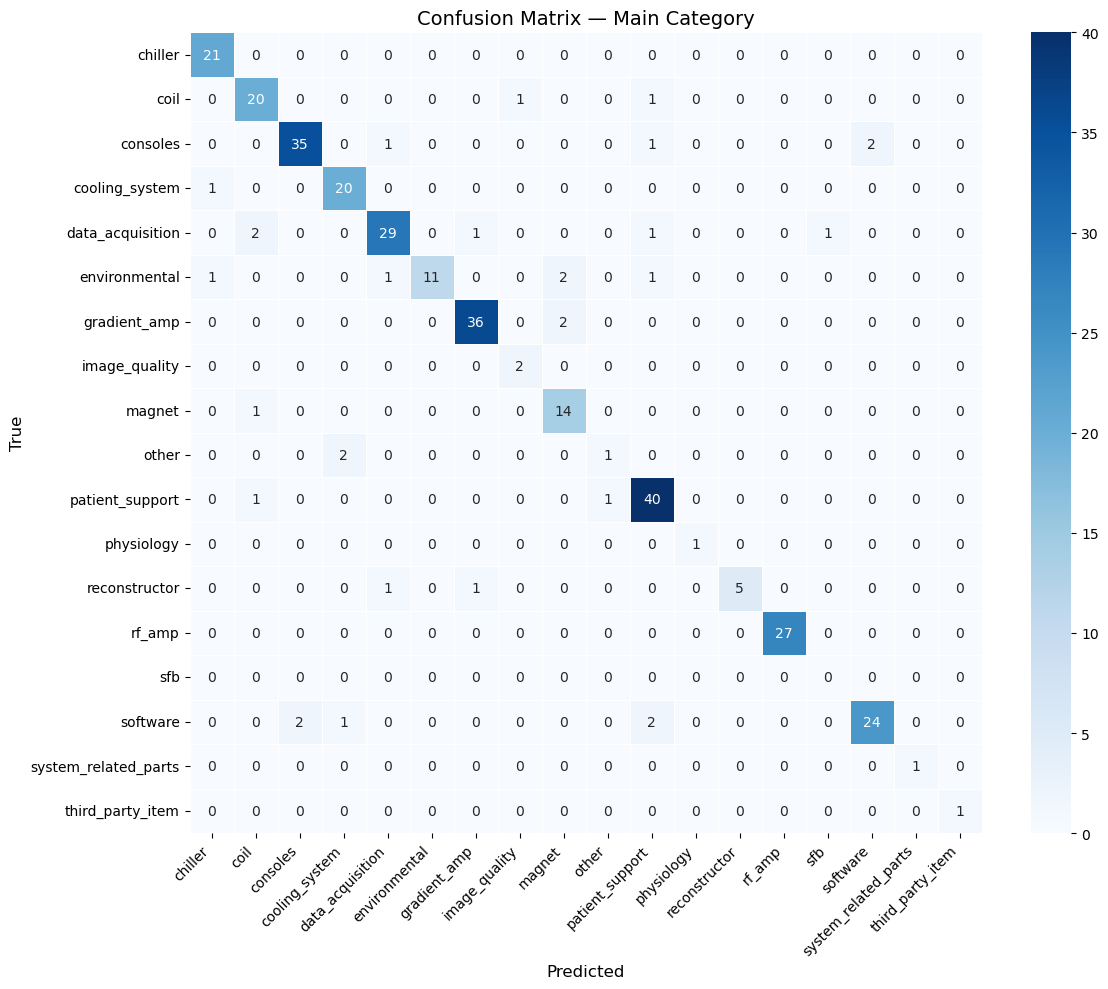

In [6]:
main_labels = sorted(set(y_true_main) | set(y_pred_main))
cm_main = confusion_matrix(y_true_main, y_pred_main, labels=main_labels)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    cm_main, annot=True, fmt="d", cmap="Blues",
    xticklabels=main_labels, yticklabels=main_labels,
    linewidths=0.5, ax=ax,
)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_title("Confusion Matrix \u2014 Main Category", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("data/reports/confusion_matrix_main.png", dpi=150, bbox_inches="tight")
plt.show()

## Main category confusion matrix (normalized)

C:\Users\320305732\AppData\Local\Temp\ipykernel_35144\3146368593.py:1: RuntimeWarning: invalid value encountered in divide
  cm_main_norm = cm_main.astype(float) / cm_main.sum(axis=1, keepdims=True)


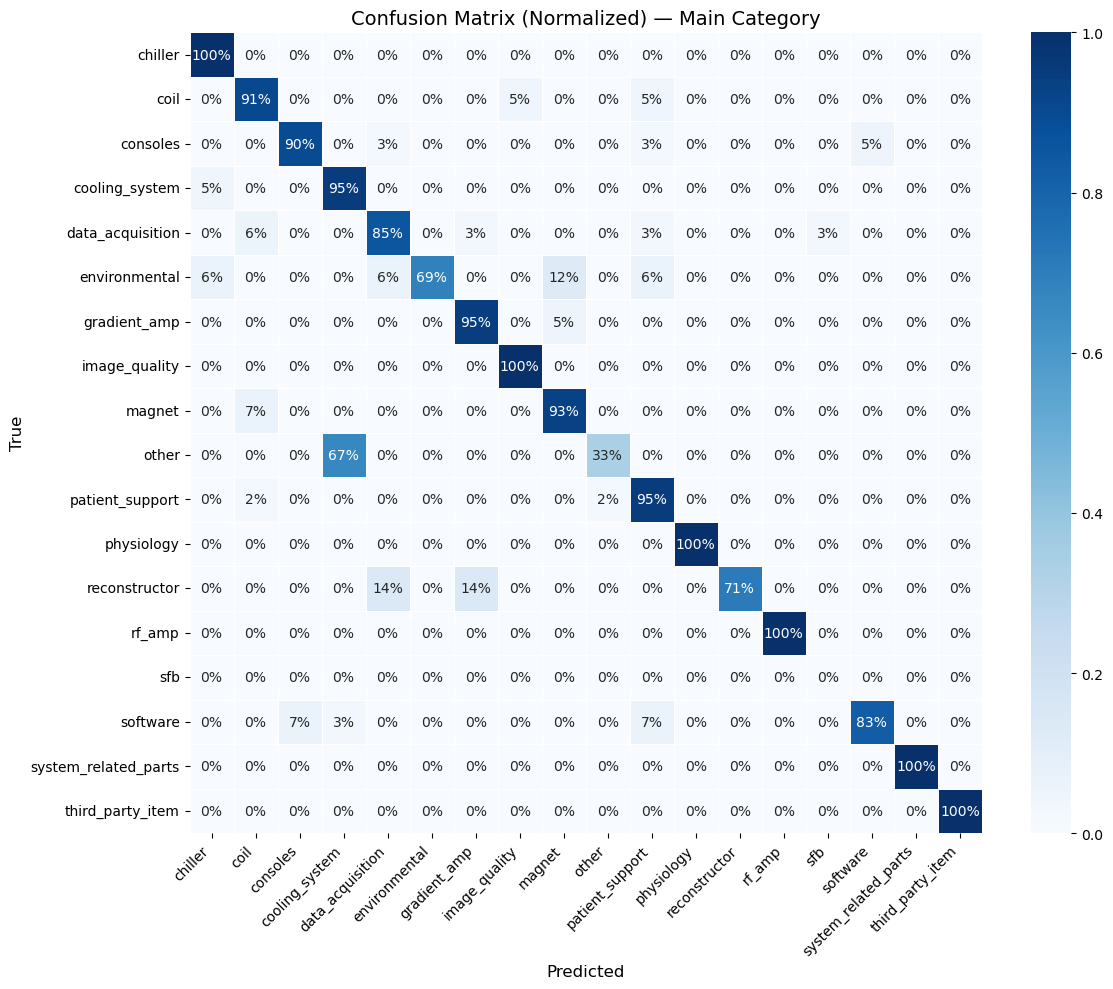

In [7]:
cm_main_norm = cm_main.astype(float) / cm_main.sum(axis=1, keepdims=True)
cm_main_norm = np.nan_to_num(cm_main_norm)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    cm_main_norm, annot=True, fmt=".0%", cmap="Blues",
    xticklabels=main_labels, yticklabels=main_labels,
    linewidths=0.5, vmin=0, vmax=1, ax=ax,
)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_title("Confusion Matrix (Normalized) \u2014 Main Category", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("data/reports/confusion_matrix_main_normalized.png", dpi=150, bbox_inches="tight")
plt.show()

## Top confusion pairs

In [8]:
print("=" * 70)
print("  TOP CONFUSION PAIRS \u2014 MAIN CATEGORY")
print("=" * 70)

mistakes_main = results[~results["main_correct"]]
if len(mistakes_main) > 0:
    pairs_main = (
        mistakes_main
        .groupby(["nam_main_category", "predicted_main"])
        .size().reset_index(name="count")
        .sort_values("count", ascending=False)
        .head(15)
    )
    pairs_main.columns = ["True", "Predicted", "Count"]
    print(pairs_main.to_string(index=False))

print(f"\n{'=' * 70}")
print("  TOP CONFUSION PAIRS \u2014 SUB CATEGORY")
print("=" * 70)

mistakes_sub = results[~results["sub_correct"]].dropna(subset=["nam_sub_category", "predicted_sub"])
if len(mistakes_sub) > 0:
    pairs_sub = (
        mistakes_sub
        .groupby(["nam_sub_category", "predicted_sub"])
        .size().reset_index(name="count")
        .sort_values("count", ascending=False)
        .head(15)
    )
    pairs_sub.columns = ["True", "Predicted", "Count"]
    print(pairs_sub.to_string(index=False))

  TOP CONFUSION PAIRS — MAIN CATEGORY
            True        Predicted  Count
data_acquisition             coil      2
        consoles         software      2
   environmental           magnet      2
        software  patient_support      2
           other   cooling_system      2
        software         consoles      2
    gradient_amp           magnet      2
            coil    image_quality      1
data_acquisition     gradient_amp      1
  cooling_system          chiller      1
        consoles data_acquisition      1
        consoles  patient_support      1
            coil  patient_support      1
   environmental data_acquisition      1
data_acquisition  patient_support      1

  TOP CONFUSION PAIRS — SUB CATEGORY
          True         Predicted  Count
        no_prs               lcc      2
  power_supply       axis_module      2
          aibo           dstream      1
  applications other_electronics      1
   axis_module         fse_aware      1
   backend_box             o

## Failure analysis: retrieval vs LLM

Diagnoses WHY cases were misclassified:
- **Type A — Retrieval failure**: retrieved examples had the wrong majority label, LLM followed them → fix retrieval or enriched text
- **Type B — LLM failure**: retrieved examples had the right majority label, but LLM disagreed → fix prompt or LLM context

In [9]:
# requires retrieval_majority_label column (saved by main.py)
if "retrieval_majority_label" not in results.columns:
    print("WARNING: retrieval_majority_label not in results CSV.")
    print("Re-run main.py to generate this column.")
else:
    failures = results[~results["main_correct"]].copy()
    failures["retrieval_correct"] = failures["retrieval_majority_label"] == failures["nam_main_category"]

    type_a = failures[~failures["retrieval_correct"]]  # retrieval wrong
    type_b = failures[failures["retrieval_correct"]]    # retrieval right, LLM wrong

    total_failures = len(failures)
    print(f"Total failures: {total_failures}/{len(results)} ({total_failures/len(results):.1%})")
    print(f"\n  Type A \u2014 Retrieval wrong, LLM wrong:  {len(type_a)} "
          f"({len(type_a)/total_failures:.0%} of failures)")
    print(f"    \u2192 Fix: improve retrieval text or add more labeled data")
    print(f"  Type B \u2014 Retrieval right, LLM wrong:  {len(type_b)} "
          f"({len(type_b)/total_failures:.0%} of failures)")
    print(f"    \u2192 Fix: improve prompt wording or LLM context")

    # per-category: retrieval accuracy vs LLM accuracy
    print(f"\n{'category':<25} {'support':>7} {'ret_acc':>8} {'llm_acc':>8} {'llm_lift':>9}")
    print("-" * 60)
    for cat in sorted(results["nam_main_category"].unique()):
        cat_rows = results[results["nam_main_category"] == cat]
        n = len(cat_rows)
        ret_correct = (cat_rows["retrieval_majority_label"] == cat).sum()
        llm_correct = cat_rows["main_correct"].sum()
        ret_acc = ret_correct / n
        llm_acc = llm_correct / n
        lift = llm_acc - ret_acc
        print(f"  {cat:<23} {n:>7} {ret_acc:>7.0%} {llm_acc:>7.0%} {lift:>+8.0%}")

Total failures: 31/319 (9.7%)

  Type A — Retrieval wrong, LLM wrong:  24 (77% of failures)
    → Fix: improve retrieval text or add more labeled data
  Type B — Retrieval right, LLM wrong:  7 (23% of failures)
    → Fix: improve prompt wording or LLM context

category                  support  ret_acc  llm_acc  llm_lift
------------------------------------------------------------
  chiller                      21     95%    100%      +5%
  coil                         22     91%     91%      +0%
  consoles                     39     82%     90%      +8%
  cooling_system               21     86%     95%     +10%
  data_acquisition             34     79%     85%      +6%
  environmental                16     56%     69%     +12%
  gradient_amp                 38     82%     95%     +13%
  image_quality                 2      0%    100%    +100%
  magnet                       15     40%     93%     +53%
  other                         3      0%     33%     +33%
  patient_support         

## Sample inspection of failures

Shows actual case text for the top confusion pairs to understand WHY the classifier fails.

In [10]:
if "retrieval_majority_label" in results.columns:
    failures = results[~results["main_correct"]].copy()
    failures["retrieval_correct"] = failures["retrieval_majority_label"] == failures["nam_main_category"]

    # ── Type A samples: retrieval gave wrong examples ──
    print("=" * 70)
    print("  TYPE A SAMPLES \u2014 Retrieval wrong, LLM couldn't recover")
    print("=" * 70)
    for i, (_, row) in enumerate(failures[~failures["retrieval_correct"]].iterrows()):
        if i >= 5:
            break
        print(f"\n  TRUE: {row['nam_main_category']}  |  PREDICTED: {row['predicted_main']}  "
              f"|  RETRIEVAL: {row['retrieval_majority_label']}")
        text = str(row.get("retrieval_text", ""))[:200]
        print(f"  Retrieval text: {text}")

    # ── Type B samples: LLM ignored good retrieval ──
    print(f"\n{'=' * 70}")
    print("  TYPE B SAMPLES \u2014 Retrieval right, LLM disagreed")
    print("=" * 70)
    for i, (_, row) in enumerate(failures[failures["retrieval_correct"]].iterrows()):
        if i >= 5:
            break
        print(f"\n  TRUE: {row['nam_main_category']}  |  PREDICTED: {row['predicted_main']}  "
              f"|  RETRIEVAL: {row['retrieval_majority_label']}")
        context = str(row.get("llm_context", ""))[:200]
        print(f"  LLM context: {context}")

  TYPE A SAMPLES — Retrieval wrong, LLM couldn't recover

  TRUE: consoles  |  PREDICTED: patient_support  |  RETRIEVAL: patient_support
  Retrieval text: Site Down - message on host " unable to start basic infrastructure services" -- customer states power shutdown has been performed 3 times [SEP] DIAGNOSTIC: Customer reset breakers and recon computer  

  TRUE: patient_support  |  PREDICTED: coil  |  RETRIEVAL: coil
  Retrieval text: Customer cannot scan, "posterior coil not connected" errors on user interface, No ring lights, [SEP] AREA: Magnet [SEP] DIAGNOSTIC: "Confirmed dStream selftest *FAILED*
Confirmed  SBM board test *FAIL

  TRUE: software  |  PREDICTED: consoles  |  RETRIEVAL: consoles
  Retrieval text: Computer is not booting up [SEP] DIAGNOSTIC: Customer said the application software not booting application and ERUI displays on magnet are blank,
Instructed customer to restart the host computer,
Log

  TRUE: reconstructor  |  PREDICTED: data_acquisition  |  RETRIEVAL: data_

## Sub-category breakdown for worst main categories

Instead of a full sub-category confusion matrix (too large to read),
this drills into sub-category performance only for the main categories
that perform worst.

In [11]:
# find the 3 worst main categories by F1
worst_cats = main_metrics.head(3)["category"].tolist()
print(f"Drilling into sub-categories for worst main categories: {worst_cats}\n")

sub_valid = results.dropna(subset=["nam_sub_category", "predicted_sub"])

for cat in worst_cats:
    cat_rows = sub_valid[sub_valid["nam_main_category"] == cat]
    if len(cat_rows) == 0:
        continue

    print(f"\n{'=' * 60}")
    print(f"  {cat.upper()} \u2014 Sub-category breakdown ({len(cat_rows)} cases)")
    print(f"{'=' * 60}")

    y_true = cat_rows["nam_sub_category"].tolist()
    y_pred = cat_rows["predicted_sub"].tolist()
    sub_met = per_category_metrics(y_true, y_pred)
    print(sub_met.to_string(index=False))

    # top confusion pairs within this main category
    wrong = cat_rows[cat_rows["nam_sub_category"] != cat_rows["predicted_sub"]]
    if len(wrong) > 0:
        pairs = (
            wrong.groupby(["nam_sub_category", "predicted_sub"])
            .size().reset_index(name="count")
            .sort_values("count", ascending=False)
            .head(5)
        )
        pairs.columns = ["True Sub", "Predicted Sub", "Count"]
        print(f"\n  Top confusion pairs:")
        print("  " + pairs.to_string(index=False).replace("\n", "\n  "))

Drilling into sub-categories for worst main categories: ['sfb', 'other', 'image_quality']


  OTHER — Sub-category breakdown (3 cases)
category  precision  recall  f1  support  correct  errors
     lcc        0.0   0.000 0.0        0        0       0
  no_prs        1.0   0.333 0.5        3        1       2

  Top confusion pairs:
  True Sub Predicted Sub  Count
    no_prs           lcc      2

  IMAGE_QUALITY — Sub-category breakdown (2 cases)
   category  precision  recall  f1  support  correct  errors
distortions        1.0     1.0 1.0        1        1       0
 spots_dots        1.0     1.0 1.0        1        1       0


## Save metrics

In [12]:
main_metrics.to_csv("data/reports/main_category_metrics.csv", index=False)
print("Saved: data/reports/main_category_metrics.csv")

# sub metrics for valid cases only
sub_valid = results.dropna(subset=["nam_sub_category", "predicted_sub"])
y_true_sub = sub_valid["nam_sub_category"].tolist()
y_pred_sub = sub_valid["predicted_sub"].tolist()
sub_metrics = per_category_metrics(y_true_sub, y_pred_sub)
sub_metrics.to_csv("data/reports/sub_category_metrics.csv", index=False)
print("Saved: data/reports/sub_category_metrics.csv")

Saved: data/reports/main_category_metrics.csv
Saved: data/reports/sub_category_metrics.csv
